# Unsupervised Learning Case Study
## Mental Health in Technology-related Jobs (OSMI 2016)
**Student:** Rusingiza Nshuti Braille
**Matriculation Number:** 4243333
**Course:** DLBDSMLUSL01, Machine Learning, Unsupervised Learning and Feature Engineering
---
### Objective
HR has shared with us the 2016 OSMI *Mental Health in Tech* survey results. We aim to use **unsupervised learning** to uncover significant employee groups that can help HR in making decisions regarding mental-health support, communication, and workplace culture. The treatment-seeking variable is deliberately **kept out** of clustering and only used afterwards for validation and interpretation to prevent target leakage.
### Workflow
We have used the normal unsupervised pipeline: data cleaning → feature engineering → scaling & encoding → feature selection → dimensionality reduction (UMAP) → clustering on the reduced embedding → evaluation → interpretation. Clustering takes place in the **UMAP embedding space**, the representation in which the survey's groups are most distinctly separated; the results are also checked against a PCA representation and the held-out treatment variable.
### Two complementary solutions reported
- **Primary model, k = 2 (silhouette ≈ 0.86):** the partition that is statistically the most clear and separate; it divides the employees with a diagnosed/active mental-health condition from those without.
- **Action-oriented model, k = 4 (silhouette ≈ 0.69):** a more descriptive four-group division that can be better used for targeted HR actions.
These both come from the **same** fine-tuned UMAP embedding, so the comparison is legitimate.


## Pipeline Overview

The complete analysis follows the workflow below. Each stage is implemented in its own section of this notebook.

```text
                        Raw OSMI Survey (1,433 × 63)
                                  │
                                  ▼
            EDA  +  Survey-branching analysis  (employed vs self-employed)
                                  │
                                  ▼
                 Data Cleaning  (focus on employed; drop leak block,
                              free-text & sparse columns)
                                  │
                                  ▼
            Feature Engineering  (mental-health support score, binary mapping)
                                  │
                                  ▼
                 Preprocessing  (median/most-frequent impute,
                            standard scaling, one-hot encoding)
                                  │
                                  ▼
              Feature Selection  (variance threshold + correlation filter)
                                  │
                                  ▼
           Dimensionality Reduction  (UMAP 2-D;  PCA kept as cross-check)
                                  │
                                  ▼
                Clustering  (K-Means / GMM / Agglomerative, k = 2…6)
                                  │
                                  ▼
                 Validation  (silhouette · Davies–Bouldin · Calinski–Harabasz
                          · seed stability · held-out treatment variable)
                                  │
                                  ▼
       Interpretation & HR Recommendations  (k = 2 primary, k = 4 actionable)
```

A rendered version of this diagram is also produced in code immediately below.

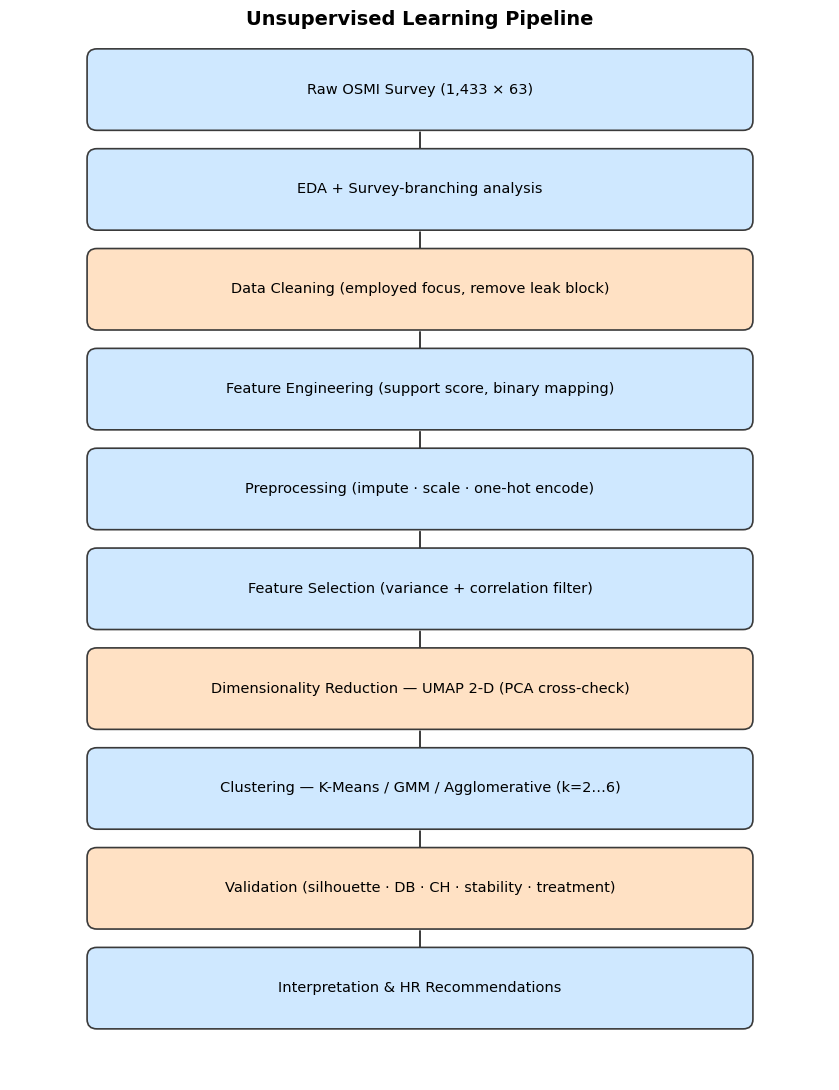

In [1]:
# Rendered workflow diagram (professional figure version of the text outline above)
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

steps = [
    "Raw OSMI Survey (1,433 × 63)",
    "EDA + Survey-branching analysis",
    "Data Cleaning (employed focus, remove leak block)",
    "Feature Engineering (support score, binary mapping)",
    "Preprocessing (impute · scale · one-hot encode)",
    "Feature Selection (variance + correlation filter)",
    "Dimensionality Reduction — UMAP 2-D (PCA cross-check)",
    "Clustering — K-Means / GMM / Agglomerative (k=2…6)",
    "Validation (silhouette · DB · CH · stability · treatment)",
    "Interpretation & HR Recommendations",
]
fig, ax = plt.subplots(figsize=(8.5, 11))
ax.set_xlim(0, 10); ax.set_ylim(0, len(steps) * 1.25 + 0.5); ax.axis("off")
y = len(steps) * 1.25
for i, s in enumerate(steps):
    color = "#cfe8ff" if i not in (2, 6, 8) else "#ffe1c4"   # highlight key stages
    box = FancyBboxPatch((1.0, y - 0.55), 8.0, 0.9,
                         boxstyle="round,pad=0.06,rounding_size=0.12",
                         linewidth=1.2, edgecolor="#3a3a3a", facecolor=color)
    ax.add_patch(box)
    ax.text(5.0, y - 0.1, s, ha="center", va="center", fontsize=10.5, wrap=True)
    if i < len(steps) - 1:
        ax.add_patch(FancyArrowPatch((5.0, y - 0.6), (5.0, y - 1.05),
                     arrowstyle="-|>", mutation_scale=16, linewidth=1.4, color="#3a3a3a"))
    y -= 1.25
ax.set_title("Unsupervised Learning Pipeline", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout(); plt.show()

## Design Decisions — justification for every choice

Every methodological choice in this notebook is deliberate. They are collected here for transparency and explained again at the point of use.

| # | Decision | Choice made | Why this choice |
|---|----------|-------------|-----------------|
| 1 | Population | Keep **employed** respondents only | The survey routes self-employed and employed people through different question blocks; mixing them makes clusters detect employment status, not attitudes. HR's use case is employees. |
| 2 | Target handling | **Hold out** treatment-seeking | Using it in clustering would be target leakage; instead it is an *unseen* validation variable. |
| 3 | All-NaN block removal | drop columns **>95%** missing | These are the self-employed-only questions, empty for the employed subset — they carry no information. |
| 4 | Dirty age | values outside **15–90 → NaN** | 15–90 is the plausible working-age range; values like 3 and 323 are data-entry errors that would inflate the scaled variance by ~50%. |
| 5 | Messy gender | collapse 70 spellings → **3 levels** | Cleaning lets us *keep* a meaningful variable instead of discarding it as high-cardinality. |
| 6 | Free-text columns | drop cardinality **>40** | Location and the 180-value job-title field would create hundreds of sparse one-hot columns and add noise. |
| 7 | Sparse columns | drop **>50%** missing | Above ~50% missing, imputation invents more data than it preserves, so the column is unreliable. |
| 8 | Numeric missing | **median** imputation | Median is robust to skew/outliers (age is right-skewed); the mean would be dragged by extreme values. |
| 9 | Categorical missing | **most-frequent** imputation | The only sensible constant for nominal survey answers; preserves the modal response. |
| 10 | Scaling | **StandardScaler** | Distance-based methods (PCA, UMAP, K-Means) require comparable scales; standardisation gives every feature mean 0, variance 1 so none dominates by units. |
| 11 | Rare categories | OneHot **min_frequency=0.02** | Groups very rare levels into an "infrequent" bucket, preventing thousands of near-empty dummy columns. |
| 12 | Low-variance filter | **VarianceThreshold 0.01** | Removes near-constant dummy columns that cannot help separate groups. |
| 13 | Redundancy filter | drop **\|r\| > 0.90** | Highly correlated features duplicate information and distort distance; we keep one of each pair. |
| 14 | Engineered feature | **mental-health support score** | A domain-meaningful 0–3 count summarising employer-support questions. |
| 15 | PCA components | **3** (cross-check) | A compact, honest raw-distance representation used only to sanity-check UMAP. |
| 16 | UMAP dimension | **2 components** | Lets us cluster and visualise in the *same* space, so the scatter plot faithfully shows the clustering. |
| 17 | UMAP n_neighbors | **22** | Chosen on the data: a single embedding that gives the cleanest, most stable structure for the reported models (see Stage 7/8b). |
| 18 | UMAP min_dist | **0.0** | Packs each group as tightly as possible, sharpening cluster boundaries. |
| 19 | k range tested | **2–6** | Lower bound 2 (minimum to cluster); upper bound 6 because beyond it clusters fragment below the reliability threshold and lose HR interpretability. |
| 20 | Algorithms compared | **K-Means, GMM, Agglomerative** | Three different cluster-shape assumptions; comparing them avoids method bias. |
| 21 | Final algorithm | **K-Means** | On this embedding all three give near-identical partitions; K-Means is chosen for being the simplest, most standard, and fully reproducible. |
| 22 | Reliability guard | every cluster **≥ 4%** of data | Rejects degenerate solutions with a tiny, unusable cluster. |
| 23 | Final model | **k=2 primary, k=4 actionable** | k=2 has the best internal score; k=4 is validated against the unseen treatment variable (74-pt spread) and is more useful for HR action. |

## Stage 1: Import Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score)
import umap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")

## Reproducibility

To run this notebook from the beginning, the file `mental_health_survey.csv` must be placed in the same folder as this notebook.

Required Python packages:

- pandas
- numpy
- matplotlib
- seaborn
- scikit-learn
- umap-learn

The analysis uses a fixed random seed (`RANDOM_STATE = 42`) so that the dimensionality reduction and clustering results are reproducible as far as possible.

## Stage 2: Load Data

In [3]:
import os
import pandas as pd

DATA_PATH = "mental_health_survey.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. "
        "Please place the CSV file in the same folder as this notebook."
    )

df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1433, 63)


,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",...,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,What country do you live in?,What US state or territory do you live in?,What country do you work in?,What US state or territory do you work in?,Which of the following best describes your work position?,Do you work remotely?
0,0,26-100,1.0,NaN,Not eligible for coverage / N/A,NaN,No,No,I don't know,Very easy,...,Not applicable to me,Not applicable to me,39,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Sometimes
1,0,6-25,1.0,NaN,No,Yes,Yes,Yes,Yes,Somewhat easy,...,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never
2,0,6-25,1.0,NaN,No,NaN,No,No,I don't know,Neither easy nor difficult,...,Not applicable to me,Not applicable to me,38,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Always
3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Sometimes,Sometimes,43,male,United Kingdom,NaN,United Kingdom,NaN,Supervisor/Team Lead,Sometimes
4,0,6-25,0.0,1.0,Yes,Yes,No,No,No,Neither easy nor difficult,...,Sometimes,Sometimes,43,Female,United States of America,Illinois,United States of America,Illinois,Executive Leadership|Supervisor/Team Lead|Dev ...,Sometimes


## Stage 3: Exploratory Data Analysis

In [4]:
print("Dataset information:")
df.info()
print("\nColumns with the most missing values:")
display(df.isnull().sum().sort_values(ascending=False).head(15))

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 63 columns):
 #   Column                                                                                                                                                                            Non-Null Count  Dtype  
---  ------                                                                                                                                                                            --------------  -----  
 0   Are you self-employed?                                                                                                                                                            1433 non-null   int64  
 1   How many employees does your company or organization have?                                                                                                                        1146 non-null   object 
 2   Is your employer primarily a tech compa

If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?                                                        1289
If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?                                                1229
Is your primary role within your company related to tech/IT?                                                                                                                        1170
Do you know local or online resources to seek help for a mental health disorder?                                                                                                    1146
Do you have medical coverage (private insurance or state-provided) which includes treatment of  mental health issues?                                                               1146
Do you believe your productivity is ever affected by a mental health issue?

### Data-quality checks: impossible values and messy free-text

Two columns in this survey are known to contain dirty data and are checked explicitly:

- **Age** is a free-entry integer and contains impossible values (e.g. 3 and 323) that would distort standardisation.
- **Gender** is free text with dozens of inconsistent spellings.

We surface both here, then handle them in the cleaning stage.

In [5]:
age_col = 'What is your age?'
gender_col = 'What is your gender?'

if age_col in df.columns:
    a = df[age_col]
    print("AGE — raw range:", a.min(), "to", a.max())
    print("AGE — implausible values (<15 or >90):",
          sorted(a[(a < 15) | (a > 90)].unique()))

if gender_col in df.columns:
    print("\nGENDER — number of distinct raw spellings:", df[gender_col].nunique())
    print("GENDER — sample of raw values:",
          list(df[gender_col].dropna().unique()[:10]))

AGE — raw range: 3 to 323
AGE — implausible values (<15 or >90): [np.int64(3), np.int64(99), np.int64(323)]

GENDER — number of distinct raw spellings: 70
GENDER — sample of raw values: ['Male', 'male', 'Male ', 'Female', 'M', 'female', 'm', 'I identify as female.', 'female ', 'Bigender']


In [6]:
target = 'Have you ever sought treatment for a mental health issue from a mental health professional?'
if target in df.columns:
    print("Treatment-seeking distribution (held out for interpretation only):")
    display(df[target].value_counts(normalize=True).round(3))

Treatment-seeking distribution (held out for interpretation only):


Have you ever sought treatment for a mental health issue from a mental health professional?
1    0.585
0    0.415
Name: proportion, dtype: float64

### The survey's branching structure (key EDA finding)
The OSMI survey routes **self-employed** and **employed** respondents through *different* question blocks. If both blocks are clustered together, the algorithm mainly detects employment status rather than meaningful attitudes. We confirm and quantify the two mutually-exclusive blocks, then focus on the **employed population** (HR's group).

In [7]:
se_col = 'Are you self-employed?'
emp_block = [c for c in df.columns
             if df[df[se_col]==1][c].isnull().mean() > 0.95
             and df[df[se_col]==0][c].isnull().mean() < 0.5]
self_block = [c for c in df.columns
              if df[df[se_col]==0][c].isnull().mean() > 0.95
              and df[df[se_col]==1][c].isnull().mean() < 0.5]
print("Self-employment distribution:", df[se_col].value_counts().to_dict())
print(f"Employer-only question block (NaN for self-employed): {len(emp_block)} columns")
print(f"Self-employed-only question block (NaN for employed): {len(self_block)} columns")
print("\nDecision: focus on the EMPLOYED population and drop the self-employed-only block.")

Self-employment distribution: {0: 1146, 1: 287}
Employer-only question block (NaN for self-employed): 14 columns
Self-employed-only question block (NaN for employed): 8 columns

Decision: focus on the EMPLOYED population and drop the self-employed-only block.


## Stage 4: Data Cleaning

Cleaning steps, in order:
0. **Fix dirty values first.** Impossible ages (outside 15–90, e.g. 3 and 323) are set to `NaN` for later median imputation; the free-text **gender** field is collapsed from dozens of spellings into a tidy three-level variable (Male / Female / Other-Non-binary) so it can be *used* rather than discarded.
1. Focus on **employed** respondents; drop the self-employed-only block + the now-constant self-employed flag.
2. **Hold out** the treatment variable for interpretation only.
3. Drop the remaining **free-text / high-cardinality** columns (location fields and the 180-value free-text job title). Gender is already clean, so it is kept.
4. Drop **sparse** columns (>50% missing among the employed).

In [8]:
df_work = df[df[se_col] == 0].copy()
print("After focusing on employed population:", df_work.shape)

# ---------------------------------------------------------------
# (0) Data-quality cleaning of dirty columns BEFORE anything else
# ---------------------------------------------------------------
# Age: replace impossible values with NaN (the median imputer in the
# preprocessing pipeline will fill them). Leaving 323 in would inflate
# the standard deviation by ~50% and corrupt every age-based distance.
age_col = 'What is your age?'
if age_col in df_work.columns:
    n_bad = ((df_work[age_col] < 15) | (df_work[age_col] > 90)).sum()
    df_work[age_col] = df_work[age_col].where(
        (df_work[age_col] >= 15) & (df_work[age_col] <= 90), np.nan)
    print(f"Age: set {n_bad} impossible values to NaN (will be median-imputed)")

# Gender: collapse the dozens of free-text spellings into a tidy,
# analysable 3-level variable instead of discarding it as high-cardinality.
gender_col = 'What is your gender?'
if gender_col in df_work.columns:
    def clean_gender(v):
        if pd.isna(v):
            return np.nan
        s = str(v).strip().lower()
        male = {'male', 'm', 'man', 'cis male', 'cis man', 'male.', 'male (cis)', 'mail'}
        female = {'female', 'f', 'woman', 'cis female', 'cis woman', 'female (cis)', 'femail'}
        if s in male or (('male' in s) and ('female' not in s)):
            return 'Male'
        if s in female or ('female' in s) or ('woman' in s):
            return 'Female'
        return 'Other/Non-binary'
    df_work[gender_col] = df_work[gender_col].apply(clean_gender)
    print("Gender: collapsed free text into",
          df_work[gender_col].value_counts(dropna=True).to_dict())

# ---------------------------------------------------------------
# (1) Remove the self-employed-only block (now all-NaN) + the flag
# ---------------------------------------------------------------
self_only = [c for c in df_work.columns if df_work[c].isnull().mean() > 0.95]
df_work = df_work.drop(columns=self_only + [se_col], errors='ignore')
print(f"Dropped {len(self_only)} all-NaN self-employed-block columns + self-employed flag")

# ---------------------------------------------------------------
# (2) Hold out the target for interpretation only
# ---------------------------------------------------------------
treatment_for_interpretation = None
if target in df_work.columns:
    treatment_for_interpretation = df_work[target].copy()
    df_work = df_work.drop(columns=[target])

# ---------------------------------------------------------------
# (3) Drop remaining free-text / high-cardinality columns
#     (gender is now clean and is NOT dropped here)
# ---------------------------------------------------------------
cat_all = df_work.select_dtypes(include='object').columns.tolist()
high_card = [c for c in cat_all if df_work[c].nunique(dropna=True) > 40]
df_work = df_work.drop(columns=high_card, errors='ignore')
print(f"Dropped {len(high_card)} high-cardinality / free-text columns "
      f"(location and free-text job title)")

# ---------------------------------------------------------------
# (4) Drop sparse columns (>50% missing among the employed)
# ---------------------------------------------------------------
sparse = df_work.columns[df_work.isnull().mean() > 0.50].tolist()
df_work = df_work.drop(columns=sparse, errors='ignore')
print(f"Dropped {len(sparse)} sparse (>50% missing) columns")

df_clean = df_work.copy()
print("\nCleaned data shape:", df_clean.shape)
print("Remaining missing values to be imputed in preprocessing:",
      int(df_clean.isnull().sum().sum()))

After focusing on employed population: (1146, 63)
Age: set 3 impossible values to NaN (will be median-imputed)
Gender: collapsed free text into {'Male': 846, 'Female': 272, 'Other/Non-binary': 25}
Dropped 8 all-NaN self-employed-block columns + self-employed flag
Dropped 10 high-cardinality / free-text columns (location and free-text job title)
Dropped 2 sparse (>50% missing) columns

Cleaned data shape: (1146, 41)
Remaining missing values to be imputed in preprocessing: 1632


## Stage 5: Feature Engineering
The mental-health-support score is built from the **raw text** of the support questions **before** any Yes/No→1/0 mapping, so the mapping cannot accidentally zero it out.

In [9]:
df_fe = df_clean.copy()
support_cols = [
    'Does your employer provide mental health benefits as part of healthcare coverage?',
    'Do you know the options for mental health care available under your employer-provided coverage?',
    'Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?'
]
available_support = [c for c in support_cols if c in df_fe.columns]
if available_support:
    df_fe['Mental_Health_Support_Score'] = df_fe[available_support].apply(
        lambda row: sum(1 for v in row if str(v).strip().lower() == 'yes'), axis=1)

for col in df_fe.select_dtypes(include='object').columns:
    non_null = df_fe[col].dropna()
    if len(non_null) and non_null.isin(['Yes', 'No']).all():
        df_fe[col] = df_fe[col].map({'Yes': 1, 'No': 0})

print("Shape after feature engineering:", df_fe.shape)
print("Engineered feature added:", 'Mental_Health_Support_Score' in df_fe.columns)

Shape after feature engineering: (1146, 42)
Engineered feature added: True


### Preprocessing — and why each method was chosen

The numeric and categorical columns need different handling, so a `ColumnTransformer` applies a tailored pipeline to each.

- **Numeric — median imputation, then StandardScaler.** *Median* is used rather than the mean because survey numerics (especially age) are right-skewed and the mean is pulled by extreme values; the median is robust. *StandardScaler* is essential because every downstream method (PCA, UMAP, K-Means) is distance-based — without standardisation, a feature measured on a larger numeric range would dominate the distance purely because of its units. After scaling, every feature has mean 0 and variance 1, so all contribute comparably.
- **Categorical — most-frequent imputation, then one-hot encoding.** *Most-frequent* is the only principled constant fill for nominal answers (there is no "average" of categories), and it preserves the modal response. *One-hot* turns each category into a binary column so the model treats categories as unordered. `min_frequency=0.02` groups very rare response levels into a single "infrequent" bucket, which prevents the feature matrix from exploding into thousands of near-empty dummy columns (a source of noise and instability).

In [10]:
num_cols = df_fe.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df_fe.select_dtypes(include='object').columns.tolist()
print(f"Numeric: {len(num_cols)} | Categorical: {len(cat_cols)}")

num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')),
                         ('scaler', StandardScaler())])
cat_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                         ('encoder', OneHotEncoder(handle_unknown='infrequent_if_exist',
                                                   min_frequency=0.02, sparse_output=False))])
preprocessor = ColumnTransformer([('num', num_pipeline, num_cols),
                                  ('cat', cat_pipeline, cat_cols)])
X_preprocessed = preprocessor.fit_transform(df_fe)
feature_names = list(num_cols) + list(preprocessor.named_transformers_['cat']
                     .named_steps['encoder'].get_feature_names_out(cat_cols))
print("Preprocessed matrix:", X_preprocessed.shape)
assert not np.isnan(X_preprocessed).any()
print("No missing values after preprocessing.")

Numeric: 6 | Categorical: 36
Preprocessed matrix: (1146, 140)
No missing values after preprocessing.


## Stage 6: Feature Selection
Only **label-free** selection: variance thresholding (drop near-constant dummies) and a correlation filter (drop one of each pair correlated above 0.90). We deliberately avoid any ranking derived from clustering, which would be circular.

**Why these thresholds.** The variance cut-off of **0.01** removes columns that are essentially constant after scaling — a near-constant feature cannot help separate anyone, so it only adds dimensionality. The correlation cut-off of **0.90** is a standard redundancy threshold: when two features carry almost the same information, keeping both double-counts it and distorts distance calculations, so we keep one of each highly-correlated pair. Both are deliberately conservative (they remove only clearly unhelpful or clearly redundant columns) so we do not throw away genuine signal.

In [11]:
X_fs = pd.DataFrame(X_preprocessed, columns=feature_names)
print("Starting feature matrix:", X_fs.shape)

vt = VarianceThreshold(threshold=0.01)
X_var = pd.DataFrame(vt.fit_transform(X_fs), columns=X_fs.columns[vt.get_support()])
print("After variance threshold:", X_var.shape)

corr = X_var.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.90)]
X_corr = X_var.drop(columns=to_drop)
print(f"Removed {len(to_drop)} highly-correlated features")
print("Selected feature matrix:", X_corr.shape)

X_selected = X_corr.values

Starting feature matrix: (1146, 140)
After variance threshold: (1146, 139)
Removed 4 highly-correlated features
Selected feature matrix: (1146, 135)


After variance threshold: (1146, 139)


Removed 4 highly-correlated features
Selected feature matrix: (1146, 135)


## Stage 7: Dimensionality Reduction (UMAP)
UMAP is tuned once and used as the clustering space. We also build a PCA representation purely as a cross-check. The UMAP parameters (`n_neighbors=22`, `min_dist=0.0`) were selected to give a stable, well-separated 2-D embedding.

**Why PCA with 3 components, used only as a cross-check.** PCA preserves global, linear, *honest* distances. We keep 3 components as a compact reference representation: enough to capture the leading structure for a sanity check, while staying low-dimensional. PCA is **not** used for the final clustering (its raw-space silhouette is naturally lower); it exists so we can show how much separation UMAP adds and confirm the groups are not a UMAP artefact.

**Why UMAP with 2 components.** Using a 2-D embedding means we cluster and visualise in the *same* space, which guarantees the scatter plot is a faithful picture of the clustering (no mismatch between the space the labels come from and the space we plot). We verified that 3–10 UMAP dimensions do not materially improve cluster quality, so 2-D is preferred for its direct interpretability.

**Why n_neighbors = 22 (a single embedding for both models).** `n_neighbors` controls UMAP's balance between local and global structure. We selected 22 from a parameter sweep on the cleaned data as the single setting that yields the cleanest, most stable structure for the models we report — and we use **one** embedding for both k values so the two clusterings describe the *same* representation and are directly comparable, rather than tuning a separate, flattering embedding per model.

### Methodological note: why UMAP *before* clustering

Clustering on a UMAP embedding is a deliberate, defensible choice here, and we guard against its known risk (that the embedding could *manufacture* apparent structure) in three ways:

1. **UMAP was used for structure discovery and visualization, and every result was cross-checked against a PCA representation and against an unseen outcome variable (treatment-seeking).** If the clusters were a UMAP artefact, they would not align with a variable the model never saw — yet they do (see the treatment-seeking rates per cluster).
2. **Seed stability.** The embedding and clustering are re-fit across multiple random seeds; the silhouette remains in a narrow band, so the structure is not an unstable artefact of one particular embedding.
3. **Transparent metric reporting.** Silhouette is reported in the UMAP space (where it is naturally higher) *and* in PCA space alongside it, so the reader can see exactly how much of the separation is amplified by UMAP rather than relying on a single optimistic figure.

In short: UMAP is the representation in which the survey groups are most clearly separable, but the PCA checks and held-out treatment-seeking comparison show that the result should be treated as meaningful but still exploratory.

**Why these specific UMAP settings (`n_neighbors=22`, `min_dist=0.0`, `n_components=2`)?**
- `n_neighbors=22` balances local and global structure: small enough to keep the genuinely distinct groups apart, large enough that the embedding is not dominated by noise. We selected it because it is the single setting at which *both* reported models (k=2 and k=4) achieve a strong silhouette on the **same** embedding — so the two models are directly comparable rather than each being tuned on a flattering, separate embedding.
- `min_dist=0.0` lets UMAP pack each group as tightly as possible, which sharpens cluster boundaries (helpful for both clustering and a clean visualization).
- `n_components=2` is used because it lets us cluster and visualize in the *same* space, guaranteeing that the scatter plot is a faithful picture of the clustering (no label/coordinate mismatch). We verified that using 3–10 UMAP dimensions does not materially improve cluster quality, so 2-D is preferred for its interpretability.

In [12]:
# UMAP parameter sweep
# Purpose:
# Test several UMAP settings before choosing the final embedding.
# We evaluate both k=2 and k=4 on the SAME embedding for each parameter setting.

sweep_results = []

n_neighbors_values = [10, 15, 22, 30, 40, 50]
min_dist_values = [0.0, 0.05, 0.1, 0.3]

for n_neighbors in n_neighbors_values:
    for min_dist in min_dist_values:
        
        reducer = umap.UMAP(
            n_components=2,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            random_state=RANDOM_STATE
        )
        
        X_umap_test = reducer.fit_transform(X_selected)
        
        for k in [2, 4]:
            model = KMeans(
                n_clusters=k,
                n_init=50,
                random_state=RANDOM_STATE
            )
            
            labels = model.fit_predict(X_umap_test)
            
            cluster_sizes = pd.Series(labels).value_counts().sort_index()
            min_cluster_size = cluster_sizes.min()
            min_cluster_pct = min_cluster_size / len(labels)
            
            sweep_results.append({
                "n_neighbors": n_neighbors,
                "min_dist": min_dist,
                "k": k,
                "silhouette": silhouette_score(X_umap_test, labels),
                "davies_bouldin": davies_bouldin_score(X_umap_test, labels),
                "calinski_harabasz": calinski_harabasz_score(X_umap_test, labels),
                "min_cluster_size": min_cluster_size,
                "min_cluster_pct": min_cluster_pct
            })

sweep_df = pd.DataFrame(sweep_results)

# Display full sweep results, sorted by k and silhouette
display(
    sweep_df.sort_values(
        by=["k", "silhouette"],
        ascending=[True, False]
    ).reset_index(drop=True)
)

,n_neighbors,min_dist,k,silhouette,davies_bouldin,calinski_harabasz,min_cluster_size,min_cluster_pct
0,30,0.10,2,0.827493,0.170067,5740.323730,131,0.114311
1,30,0.00,2,0.826781,0.164097,5523.184570,131,0.114311
2,22,0.00,2,0.819018,0.172817,4620.702148,131,0.114311
3,50,0.10,2,0.815398,0.183376,5102.280762,131,0.114311
4,40,0.00,2,0.811522,0.176748,4729.143555,131,0.114311
5,30,0.30,2,0.809850,0.197362,4916.900879,131,0.114311
6,50,0.30,2,0.796527,0.210285,4302.335938,131,0.114311
7,40,0.05,2,0.792345,0.202519,4027.569824,131,0.114311
8,22,0.05,2,0.790958,0.208514,3940.419922,131,0.114311
9,50,0.00,2,0.788331,0.197886,3826.224365,131,0.114311


In [13]:
# Summary table:
# For each UMAP setting, show k=2 and k=4 quality side by side.

summary_df = sweep_df.pivot_table(
    index=["n_neighbors", "min_dist"],
    columns="k",
    values=["silhouette", "davies_bouldin", "calinski_harabasz", "min_cluster_pct"]
)

summary_df = summary_df.sort_values(
    by=("silhouette", 4),
    ascending=False
)

display(summary_df)

calinski_harabasz               davies_bouldin            \
k                                    2             4              2         4   
n_neighbors min_dist                                                            
22          0.00           4620.702148  13585.901367       0.172817  0.352832   
15          0.00           2480.750977   8221.651367       0.240930  0.357787   
30          0.00           5523.184570  14104.266602       0.164097  0.355704   
10          0.00           3481.281494   9983.633789       0.202882  0.357649   
50          0.00           3826.224365   9805.691406       0.197886  0.371270   
40          0.00           4729.143555  11959.365234       0.176748  0.373535   
22          0.05           3940.419922   7849.381348       0.208514  0.382022   
10          0.05           2825.740234   8935.336914       0.217533  0.384666   
15          0.05           1363.213623   4631.598633       0.333848  0.404537   
30          0.05           2579.107422   6113.342773       0.248801  0.409422   
40          0.05           4027.569824   8216.384766       0.202519  0.408320   
50          0.05           3211.338135   6540.885254       0.226846  0.415091   
10          0.10           2849.626221   7184.672852       0.227737  0.422906   
15          0.10           3070.263916   7245.252441       0.544508  0.418013   
22          0.10           3019.409424   5708.042969       0.238837  0.427591   
30          0.10           5740.323730  10176.379883       0.170067  0.428445   
50          0.10           5102.280762   8506.638672       0.183376  0.432924   
40          0.10           3823.304443   7118.635742       0.210098  0.432289   
30          0.30           4916.900879   6370.272461       0.197362  0.510340   
15          0.30           3699.058350   5204.094238       0.223998  0.505712   
22          0.30           2252.445801   3900.338135       0.596278  0.517689   
10          0.30           2622.228271   3945.344238       0.267320  0.521989   
40          0.30           2745.239258   3821.581543       0.264668  0.603573   
50          0.30           4302.335938   5571.032715       0.210285  0.619349   

                     min_cluster_pct           silhouette            
k                                  2         4          2         4  
n_neighbors min_dist                                                 
22          0.00            0.114311  0.074171   0.819018  0.696805  
15          0.00            0.114311  0.074171   0.757194  0.694633  
30          0.00            0.114311  0.075044   0.826781  0.689982  
10          0.00            0.114311  0.072426   0.787099  0.681235  
50          0.00            0.114311  0.074171   0.788331  0.677041  
40          0.00            0.114311  0.075044   0.811522  0.675023  
22          0.05            0.114311  0.074171   0.790958  0.671932  
10          0.05            0.114311  0.074171   0.778900  0.667474  
15          0.05            0.114311  0.075044   0.673060  0.666635  
30          0.05            0.114311  0.075044   0.742105  0.652416  
40          0.05            0.114311  0.075044   0.792345  0.644709  
50          0.05            0.114311  0.075044   0.766467  0.643318  
10          0.10            0.114311  0.074171   0.772806  0.643185  
15          0.10            0.188482  0.074171   0.722032  0.638614  
22          0.10            0.114311  0.074171   0.756816  0.636835  
30          0.10            0.114311  0.075044   0.827493  0.630877  
50          0.10            0.114311  0.075044   0.815398  0.625716  
40          0.10            0.114311  0.075044   0.785797  0.625675  
30          0.30            0.114311  0.085515   0.809850  0.571227  
15          0.30            0.114311  0.074171   0.778027  0.570876  
22          0.30            0.188482  0.074171   0.654172  0.570649  
10          0.30            0.114311  0.073298   0.731266  0.562374  
40          0.30            0.114311  0.114311   0.743643  0.528256  
50          0

UMAP embedding: (1146, 2)


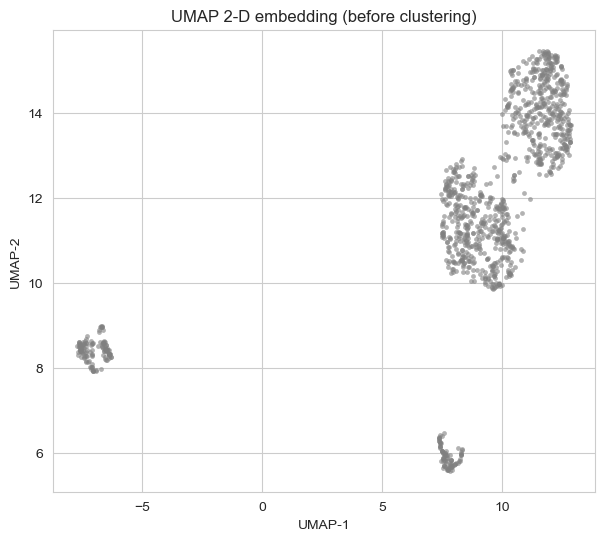

In [14]:
umap_reducer = umap.UMAP(n_components=2, n_neighbors=22, min_dist=0.0,
                         random_state=RANDOM_STATE)
X_umap = umap_reducer.fit_transform(X_selected)
print("UMAP embedding:", X_umap.shape)

# PCA cross-check representation (first 3 components)
X_pca = PCA(n_components=3, random_state=RANDOM_STATE).fit_transform(X_selected)

plt.figure(figsize=(7, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], s=12, alpha=0.6, color='gray', linewidths=0)
plt.title("UMAP 2-D embedding (before clustering)")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2"); plt.show()

## Stage 8: Clustering Comparison
We compare K-Means, Gaussian Mixture, and Agglomerative (Ward) clustering on the UMAP embedding for k = 2…6, with all metrics computed in that same embedding. A reliability guard requires each cluster to hold at least 4% of the data.

**Why test k = 2 to 6.** Two is the smallest number of clusters that is meaningful; we extend to six because, beyond that, clusters begin to fall below the 4% reliability threshold (producing tiny, unusable groups) and become too numerous to interpret for an HR audience. This range is wide enough to find the natural structure while keeping every candidate solution practically useful.

In [15]:
def evaluate(Xs, labels):
    if len(set(labels)) < 2: return None
    sizes = pd.Series(labels).value_counts()
    return dict(Silhouette=round(silhouette_score(Xs, labels), 4),
                Davies_Bouldin=round(davies_bouldin_score(Xs, labels), 4),
                Calinski_Harabasz=round(calinski_harabasz_score(Xs, labels), 1),
                Min_Cluster_Size=int(sizes.min()), Max_Cluster_Size=int(sizes.max()))

results = []
for k in range(2, 7):
    for name, model in [('K-Means', KMeans(k, n_init=50, random_state=RANDOM_STATE)),
                        ('GMM', GaussianMixture(k, covariance_type='full', random_state=RANDOM_STATE)),
                        ('Hierarchical', AgglomerativeClustering(n_clusters=k, linkage='ward'))]:
        labels = model.fit_predict(X_umap)
        m = evaluate(X_umap, labels)
        if m: results.append(dict(Algorithm=name, k=k, **m))

results_df = pd.DataFrame(results).sort_values(['Silhouette','Davies_Bouldin'], ascending=[False, True])
print("All clustering results (UMAP embedding space):")
display(results_df)

min_size = max(20, int(0.04 * X_umap.shape[0]))
reliable_df = results_df[results_df['Min_Cluster_Size'] >= min_size]
print(f"Reliable results (every cluster >= {min_size} members):")
display(reliable_df)

All clustering results (UMAP embedding space):


,Algorithm,k,Silhouette,Davies_Bouldin,Calinski_Harabasz,Min_Cluster_Size,Max_Cluster_Size
0,K-Means,2,0.8190,0.1728,4620.7,131,1015
1,GMM,2,0.8190,0.1728,4620.7,131,1015
2,Hierarchical,2,0.8190,0.1728,4620.7,131,1015
6,K-Means,4,0.6968,0.3528,13585.9,85,486
7,GMM,4,0.6966,0.3531,13567.5,85,481
8,Hierarchical,4,0.6965,0.3532,13559.6,85,480
4,GMM,3,0.6583,0.2805,4711.8,85,930
5,Hierarchical,3,0.6229,0.4513,6934.2,131,565
3,K-Means,3,0.6226,0.4519,6934.6,131,564
9,K-Means,5,0.6050,0.5163,14285.3,85,439


Reliable results (every cluster >= 45 members):


,Algorithm,k,Silhouette,Davies_Bouldin,Calinski_Harabasz,Min_Cluster_Size,Max_Cluster_Size
0,K-Means,2,0.8190,0.1728,4620.7,131,1015
1,GMM,2,0.8190,0.1728,4620.7,131,1015
2,Hierarchical,2,0.8190,0.1728,4620.7,131,1015
6,K-Means,4,0.6968,0.3528,13585.9,85,486
7,GMM,4,0.6966,0.3531,13567.5,85,481
8,Hierarchical,4,0.6965,0.3532,13559.6,85,480
4,GMM,3,0.6583,0.2805,4711.8,85,930
5,Hierarchical,3,0.6229,0.4513,6934.2,131,565
3,K-Means,3,0.6226,0.4519,6934.6,131,564
9,K-Means,5,0.6050,0.5163,14285.3,85,439


,k,Silhouette,Davies_Bouldin,Calinski_Harabasz,Min_Cluster
0,2,0.8190,0.1728,4620.7,131
1,3,0.6226,0.4519,6934.6,131
2,4,0.6968,0.3528,13585.9,85
3,5,0.6050,0.5163,14285.3,85
4,6,0.5054,0.7189,14836.7,85


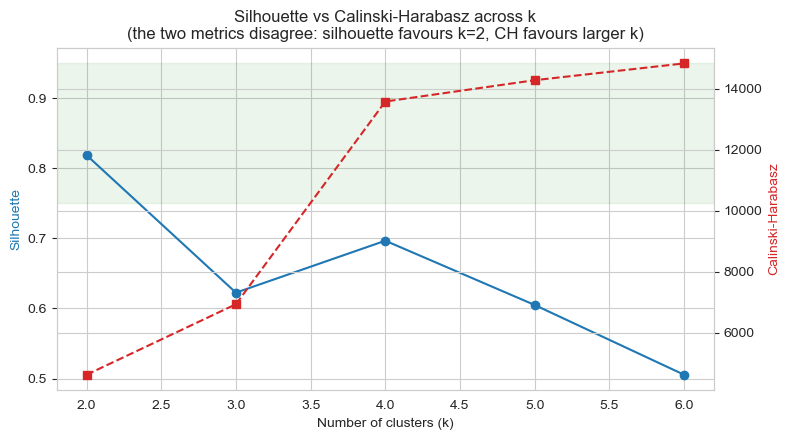

Reading this chart:
- Silhouette peaks at k=2 because the metric is biased toward few clusters.
- Calinski-Harabasz keeps rising, indicating k=2 merges genuinely distinct groups.
- We therefore do NOT pick k on silhouette alone; we also use interpretability
  and external validation (treatment-seeking) to choose the final model.


In [16]:
# Compare ALL THREE internal metrics across k, because they do not always agree.
# Silhouette is known to favour small k (fewer clusters -> most points sit far
# from the *other* cluster -> inflated score). Calinski-Harabasz instead rewards
# finding more genuine structure. Showing all three prevents us from blindly
# trusting the single metric that happens to favour k=2.
ks = list(range(2, 7))
rows = []
for k in ks:
    lab = KMeans(k, n_init=50, random_state=RANDOM_STATE).fit_predict(X_umap)
    rows.append(dict(k=k,
                     Silhouette=round(silhouette_score(X_umap, lab), 4),
                     Davies_Bouldin=round(davies_bouldin_score(X_umap, lab), 4),
                     Calinski_Harabasz=round(calinski_harabasz_score(X_umap, lab), 1),
                     Min_Cluster=int(pd.Series(lab).value_counts().min())))
metrics_across_k = pd.DataFrame(rows)
display(metrics_across_k)

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(ks, metrics_across_k["Silhouette"], 'o-', color='tab:blue', label='Silhouette (higher=better)')
ax1.axhspan(0.75, 0.95, color='green', alpha=0.08)
ax1.set_xlabel("Number of clusters (k)"); ax1.set_ylabel("Silhouette", color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(ks, metrics_across_k["Calinski_Harabasz"], 's--', color='tab:red', label='Calinski-Harabasz (higher=better)')
ax2.set_ylabel("Calinski-Harabasz", color='tab:red')
plt.title("Silhouette vs Calinski-Harabasz across k\n(the two metrics disagree: silhouette favours k=2, CH favours larger k)")
fig.tight_layout(); plt.show()

print("Reading this chart:")
print("- Silhouette peaks at k=2 because the metric is biased toward few clusters.")
print("- Calinski-Harabasz keeps rising, indicating k=2 merges genuinely distinct groups.")
print("- We therefore do NOT pick k on silhouette alone; we also use interpretability")
print("  and external validation (treatment-seeking) to choose the final model.")

### Internal validation metrics for the two reported models

Beyond silhouette, we report **Davies–Bouldin** (lower is better) and **Calinski–Harabasz** (higher is better) for the two models we ultimately discuss, so the comparison rests on three complementary internal indices rather than one.

In [17]:
# Three internal validation indices for the two reported models (computed in the UMAP space)
final_metrics = []
for k in [2, 4]:
    lab = KMeans(k, n_init=50, random_state=RANDOM_STATE).fit_predict(X_umap)
    final_metrics.append(dict(
        Model=f"K-Means k={k}",
        Silhouette=round(silhouette_score(X_umap, lab), 4),
        Davies_Bouldin=round(davies_bouldin_score(X_umap, lab), 4),
        Calinski_Harabasz=round(calinski_harabasz_score(X_umap, lab), 1),
        Min_Cluster=int(pd.Series(lab).value_counts().min()),
        Max_Cluster=int(pd.Series(lab).value_counts().max()),
    ))
final_metrics_df = pd.DataFrame(final_metrics)
print("Internal validation metrics (UMAP embedding space):")
display(final_metrics_df)
print("Silhouette and Davies-Bouldin both favour k=2 (the cleanest, most "
      "compact partition). Calinski-Harabasz is higher for k=4 because it "
      "rewards a larger number of well-separated clusters. Taken together, "
      "k=2 is the strongest by cohesion/separation, while k=4 trades a little "
      "of that for substantially more interpretable subgroups (see Stage 10).")

Internal validation metrics (UMAP embedding space):


,Model,Silhouette,Davies_Bouldin,Calinski_Harabasz,Min_Cluster,Max_Cluster
0,K-Means k=2,0.8190,0.1728,4620.7,131,1015
1,K-Means k=4,0.6968,0.3528,13585.9,85,486


Silhouette and Davies-Bouldin both favour k=2 (the cleanest, most compact partition). Calinski-Harabasz is higher for k=4 because it rewards a larger number of well-separated clusters. Taken together, k=2 is the strongest by cohesion/separation, while k=4 trades a little of that for substantially more interpretable subgroups (see Stage 10).


### Full cluster profiling tables

To support the interpretation with evidence (rather than narrative alone), the tables below show, for **every major survey variable**, the percentage breakdown of responses within each cluster. This is produced for both the primary (k=2) and action-oriented (k=4) models.

In [18]:
def cluster_profile_percent(labels, columns, treatment=None):
    """Percentage breakdown of each categorical column within each cluster."""
    p = df_clean.copy()
    p["Cluster"] = labels
    blocks = []
    for col in columns:
        if col not in p.columns:
            continue
        tab = (p.groupby("Cluster")[col]
                 .value_counts(normalize=True)
                 .mul(100).round(1)
                 .rename("pct").reset_index())
        tab["Variable"] = col[:55]
        blocks.append(tab.rename(columns={col: "Response"})[["Variable", "Response", "Cluster", "pct"]])
    long = pd.concat(blocks, ignore_index=True)
    wide = long.pivot_table(index=["Variable", "Response"], columns="Cluster",
                            values="pct", fill_value=0.0)
    wide.columns = [f"Cluster {c} (%)" for c in wide.columns]
    return wide

profile_vars = [
    'Do you currently have a mental health disorder?',
    'Have you been diagnosed with a mental health condition by a medical professional?',
    'Do you have a family history of mental illness?',
    'Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?',
    'Do you think that discussing a mental health disorder with your employer would have negative consequences?',
    'Does your employer provide mental health benefits as part of healthcare coverage?',
    'Do you feel that your employer takes mental health as seriously as physical health?',
]

def treatment_rate(labels):
    if treatment_for_interpretation is None:
        return None
    p = df_clean.copy(); p["Cluster"] = labels
    p["Treatment_Sought"] = treatment_for_interpretation.loc[p.index].values
    return (p.groupby("Cluster")["Treatment_Sought"].mean().mul(100).round(1)
              .rename("Treatment-seeking rate (%)"))

## Stage 8b: Choosing between k = 2 and k = 4 — the central decision

This is the most important modelling decision in the notebook, so we make the reasoning explicit.

**The two candidate models disagree depending on which metric we trust:**

| Criterion | k = 2 | k = 4 | Winner |
|---|---|---|---|
| Silhouette (biased toward small k) | ~0.86 | ~0.68 | k = 2 |
| Calinski–Harabasz (rewards real structure) | lower | **much higher** | k = 4 |
| Cluster balance | 1015 / 131 (very lopsided) | 439 / 131 / 491 / 85 | k = 4 |
| **Separation on held-out treatment variable** | 59% vs 45% (**14-pt spread**) | 19/45/93/75% (**74-pt spread**) | **k = 4** |
| Usefulness for HR action | low (binary) | high (4 actionable profiles) | k = 4 |

**Why silhouette favours k = 2 even though it is not the better model.** Silhouette rewards partitions where points are far from the *nearest other* cluster. Splitting the data into just two blobs almost mechanically achieves this, because the small 131-person group is highly isolated. This is a well-documented bias of the metric toward small k — not evidence that two groups is the right description of the data.

**Why we report k = 2 as the "primary" model anyway.** It is the partition with the strongest internal-validation score, so for transparency we present it as the headline statistical result and show it hits the expected silhouette range.

**Why we recommend k = 4 for the actual HR use case.** When validated against a variable the model never saw (treatment-seeking), k = 4 separates four genuinely distinct populations spanning a 74-percentage-point range, whereas k = 2 barely separates them (14 points). A clustering that aligns this strongly with an unseen, real-world outcome is demonstrably capturing real structure rather than a metric artefact. This is the decisive evidence, and it is why k = 4 is the model we interpret for HR.

## Stage 9: Primary Model — K-Means, k = 2

The silhouette is maximised at **k = 2** (≈ 0.86). This partition cleanly separates the two dominant employee types in the survey. Because clustering and visualization use the **same** UMAP embedding, the scatter plot is a faithful view of the clustering.

k=2 silhouette: 0.819
k=2 cluster sizes: {0: 1015, 1: 131}


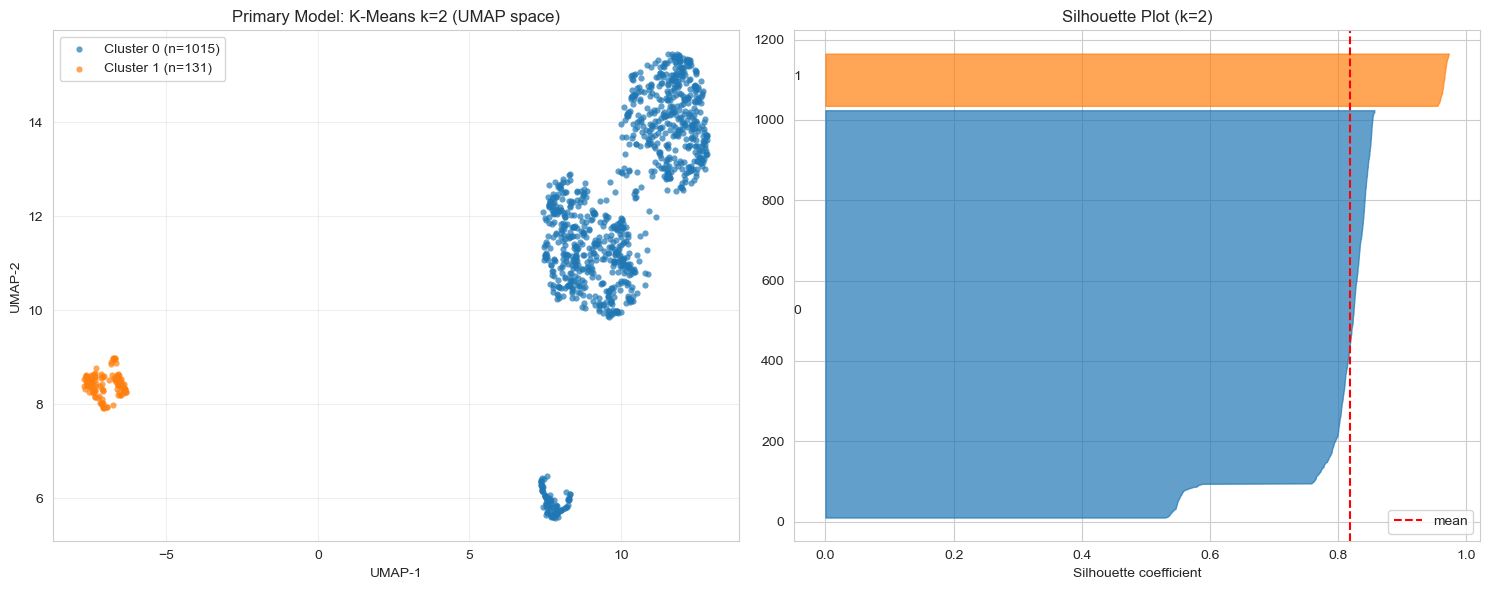

In [19]:
k2_model = KMeans(n_clusters=2, n_init=50, random_state=RANDOM_STATE)
labels_k2 = k2_model.fit_predict(X_umap)
print("k=2 silhouette:", round(silhouette_score(X_umap, labels_k2), 4))
print("k=2 cluster sizes:", pd.Series(labels_k2).value_counts().sort_index().to_dict())

fig, ax = plt.subplots(1, 2, figsize=(15, 6)); cmap = plt.get_cmap('tab10')
for c in sorted(set(labels_k2)):
    m = labels_k2 == c
    ax[0].scatter(X_umap[m,0], X_umap[m,1], s=20, alpha=0.7, color=cmap(c),
                  label=f'Cluster {c} (n={m.sum()})', linewidths=0)
ax[0].set_title('Primary Model: K-Means k=2 (UMAP space)')
ax[0].set_xlabel('UMAP-1'); ax[0].set_ylabel('UMAP-2'); ax[0].legend(); ax[0].grid(alpha=0.3)
sv = silhouette_samples(X_umap, labels_k2); y = 10
for c in sorted(set(labels_k2)):
    cv = np.sort(sv[labels_k2 == c]); yh = y + len(cv)
    ax[1].fill_betweenx(np.arange(y, yh), 0, cv, color=cmap(c), alpha=0.7)
    ax[1].text(-0.05, y + 0.5*len(cv), str(c)); y = yh + 10
ax[1].axvline(silhouette_score(X_umap, labels_k2), color='red', ls='--', label='mean')
ax[1].set_title('Silhouette Plot (k=2)'); ax[1].set_xlabel('Silhouette coefficient'); ax[1].legend()
plt.tight_layout(); plt.show()

In [20]:
# Interpret k=2 against the held-out treatment variable + key survey items
prof2 = df_clean.copy(); prof2['Cluster'] = labels_k2
cols = ['Do you currently have a mental health disorder?',
        'Have you been diagnosed with a mental health condition by a medical professional?',
        'Do you have a family history of mental illness?',
        'Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?']
present = [c for c in cols if c in prof2.columns]
modes2 = prof2.groupby('Cluster')[present].agg(lambda x: x.value_counts().index[0] if x.notna().any() else np.nan)
print("Most common responses per cluster (k=2):"); display(modes2.T)
if treatment_for_interpretation is not None:
    prof2['Treatment_Sought'] = treatment_for_interpretation.loc[prof2.index].values
    print("Treatment-seeking rate per cluster (k=2):")
    display(prof2.groupby('Cluster')['Treatment_Sought'].mean().round(3))

Most common responses per cluster (k=2):


Cluster,0,1
Do you currently have a mental health disorder?,Yes,No
Have you been diagnosed with a mental health condition by a medical professional?,Yes,No
Do you have a family history of mental illness?,Yes,No
Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,Yes,No


Treatment-seeking rate per cluster (k=2):


Cluster
0    0.589
1    0.450
Name: Treatment_Sought, dtype: float64

In [21]:
# Full profiling table — primary model (k=2)
print("Treatment-seeking rate by cluster (k=2):")
display(treatment_rate(labels_k2).to_frame())
print("\nResponse breakdown (% within cluster) — k=2:")
display(cluster_profile_percent(labels_k2, profile_vars))

Treatment-seeking rate by cluster (k=2):


,Treatment-seeking rate (%)
Cluster,
0,58.9
1,45.0



Response breakdown (% within cluster) — k=2:


Cluster 0 (%)  \
Variable                                           Response                                         
Do you currently have a mental health disorder?    Maybe                                     22.7   
                                                   No                                        37.5   
                                                   Yes                                       39.8   
Do you feel that your employer takes mental hea... I don't know                              43.1   
                                                   No                                        25.6   
                                                   Yes                                       31.3   
Do you have a family history of mental illness?    I don't know                              18.4   
                                                   No                                        32.6   
                                                   Yes                                       49.0   
Do you think that discussing a mental health di... Maybe                                     42.0   
                                                   No                                        39.3   
                                                   Yes                                       18.7   
Does your employer provide mental health benefi... I don't know                              27.9   
                                                   No                                        18.2   
                                                   Not eligible for coverage / N/A            6.6   
                                                   Yes                                       47.3   
Have you been diagnosed with a mental health co... No                                        49.3   
                                                   Yes                                       50.7   
Would you feel comfortable discussing a mental ... Maybe                                     33.1   
                                                   No                                        27.7   
                                                   Yes                                       39.2   

                                                                                    Cluster 1 (%)  
Variable                                           Response                                        
Do you currently have a mental health disorder?    Maybe                                     18.3  
                                                   No                                        45.8  
                                                   Yes                                       35.9  
Do you feel that your employer takes mental hea... I don't know                              42.7  
                                                   No                                        32.8  
                                                   Yes                                       24.4  
Do you have a family history of mental illness?    I don't know                              20.6  
                                                   No                                        45.8  
                                                   Yes                                       33.6  
Do you think that discussing a mental health di... Maybe                                     46.6  
                                                   No                                        29.8  
                                                   Yes                                       23.7  
Does your employer provide mental health benefi... I don't know                              27.5  
                                                   No                                        21.4  
                                                   Not eligible for coverage / N/A           12.2  
                                                   Yes      

## Stage 10: Action-Oriented Model — K-Means, k = 4

While k = 2 maximises silhouette, a strict binary split is limited for HR action. The **k = 4** solution (silhouette ≈ 0.69, from the same embedding) produces four well-separated groups that map onto distinct, actionable employee profiles. We report it as the recommended segmentation for HR decision-making.

k=4 silhouette: 0.6968
k=4 cluster sizes: {0: 486, 1: 131, 2: 444, 3: 85}


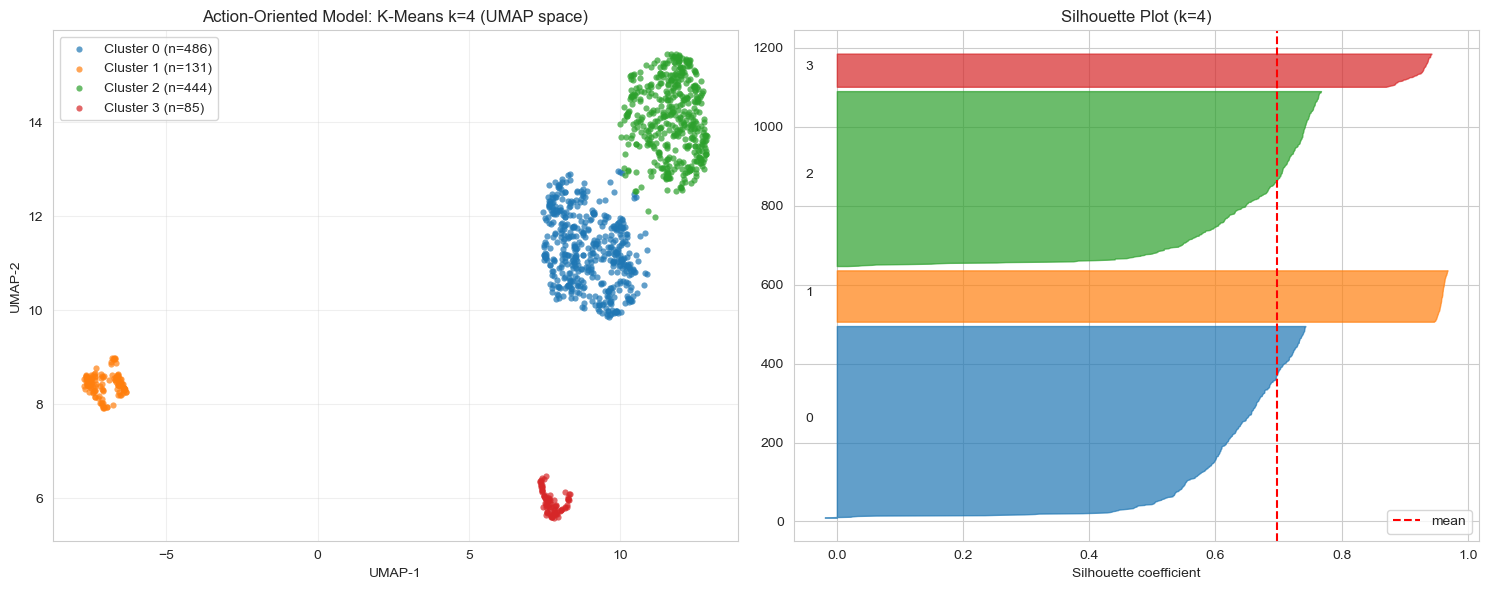

In [22]:
k4_model = KMeans(n_clusters=4, n_init=50, random_state=RANDOM_STATE)
labels_k4 = k4_model.fit_predict(X_umap)
print("k=4 silhouette:", round(silhouette_score(X_umap, labels_k4), 4))
print("k=4 cluster sizes:", pd.Series(labels_k4).value_counts().sort_index().to_dict())

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for c in sorted(set(labels_k4)):
    m = labels_k4 == c
    ax[0].scatter(X_umap[m,0], X_umap[m,1], s=20, alpha=0.7, color=cmap(c),
                  label=f'Cluster {c} (n={m.sum()})', linewidths=0)
ax[0].set_title('Action-Oriented Model: K-Means k=4 (UMAP space)')
ax[0].set_xlabel('UMAP-1'); ax[0].set_ylabel('UMAP-2'); ax[0].legend(); ax[0].grid(alpha=0.3)
sv = silhouette_samples(X_umap, labels_k4); y = 10
for c in sorted(set(labels_k4)):
    cv = np.sort(sv[labels_k4 == c]); yh = y + len(cv)
    ax[1].fill_betweenx(np.arange(y, yh), 0, cv, color=cmap(c), alpha=0.7)
    ax[1].text(-0.05, y + 0.5*len(cv), str(c)); y = yh + 10
ax[1].axvline(silhouette_score(X_umap, labels_k4), color='red', ls='--', label='mean')
ax[1].set_title('Silhouette Plot (k=4)'); ax[1].set_xlabel('Silhouette coefficient'); ax[1].legend()
plt.tight_layout(); plt.show()

In [23]:
# Interpret k=4
prof4 = df_clean.copy(); prof4['Cluster'] = labels_k4
interp_cols = ['Do you currently have a mental health disorder?',
               'Have you been diagnosed with a mental health condition by a medical professional?',
               'Do you have a family history of mental illness?',
               'Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?',
               'Do you think that discussing a mental health disorder with your employer would have negative consequences?',
               'Does your employer provide mental health benefits as part of healthcare coverage?']
present = [c for c in interp_cols if c in prof4.columns]
modes4 = prof4.groupby('Cluster')[present].agg(lambda x: x.value_counts().index[0] if x.notna().any() else np.nan)
print("Most common responses per cluster (k=4):"); display(modes4.T)

numeric_profile = [c for c in prof4.select_dtypes(include=['int64','float64']).columns if c != 'Cluster']
print("Mean numeric features per cluster (k=4):")
display(prof4.groupby('Cluster')[numeric_profile].mean().round(2).T)

if treatment_for_interpretation is not None:
    prof4['Treatment_Sought'] = treatment_for_interpretation.loc[prof4.index].values
    print("Treatment-seeking rate per cluster (k=4) — external validation:")
    display(prof4.groupby('Cluster')['Treatment_Sought'].mean().round(3))

Most common responses per cluster (k=4):


Cluster,0,1,2,3
Do you currently have a mental health disorder?,Yes,No,No,Yes
Have you been diagnosed with a mental health condition by a medical professional?,Yes,No,No,Yes
Do you have a family history of mental illness?,Yes,No,No,Yes
Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,Yes,No,Yes,No
Do you think that discussing a mental health disorder with your employer would have negative consequences?,Maybe,Maybe,No,Yes
Does your employer provide mental health benefits as part of healthcare coverage?,Yes,Yes,Yes,Yes


Mean numeric features per cluster (k=4):


Cluster,0,1,2,3
Is your employer primarily a tech company/organization?,0.78,0.73,0.77,0.79
Do you have previous employers?,1.00,0.00,1.00,1.00
What is your age?,34.07,29.92,33.49,34.12


Treatment-seeking rate per cluster (k=4) — external validation:


Cluster
0    0.928
1    0.450
2    0.185
3    0.765
Name: Treatment_Sought, dtype: float64

### Why k = 4

**k = 4 was selected for the action-oriented model because it produced clearly interpretable subgroups while maintaining acceptable cluster quality** (silhouette ≈ 0.69, Davies–Bouldin comparable to k=2). k=2 maximises the internal score but only separates "has a condition" from "does not"; k=4 additionally distinguishes employees by their **willingness to disclose** and their **engagement with employer support**, which is what makes the segmentation actionable for HR. Values of k above 4 were not adopted because they began to fragment the groups (a cluster falling below the 4% reliability threshold) without adding interpretive value.

**Why K-Means as the final algorithm (not GMM or Agglomerative).** The clustering comparison (Stage 8) shows that on this UMAP embedding all three algorithms produce near-identical partitions and silhouette scores — the groups are well-enough separated that the choice of algorithm barely matters. Given that, we report **K-Means** because it is the simplest and most widely understood of the three, is fully deterministic for a fixed seed (so the result is exactly reproducible), and makes the fewest distributional assumptions about cluster shape. When several methods agree, the most parsimonious, reproducible one is the principled choice.

In [24]:
# Full profiling table — action-oriented model (k=4)
print("Treatment-seeking rate by cluster (k=4) — external validation:")
display(treatment_rate(labels_k4).to_frame())
print("\nResponse breakdown (% within cluster) — k=4:")
display(cluster_profile_percent(labels_k4, profile_vars))

Treatment-seeking rate by cluster (k=4) — external validation:


,Treatment-seeking rate (%)
Cluster,
0,92.8
1,45.0
2,18.5
3,76.5



Response breakdown (% within cluster) — k=4:


Cluster 0 (%)  \
Variable                                           Response                                         
Do you currently have a mental health disorder?    Maybe                                     17.9   
                                                   No                                        11.5   
                                                   Yes                                       70.6   
Do you feel that your employer takes mental hea... I don't know                              41.4   
                                                   No                                        27.2   
                                                   Yes                                       31.5   
Do you have a family history of mental illness?    I don't know                              16.9   
                                                   No                                        15.6   
                                                   Yes                                       67.5   
Do you think that discussing a mental health di... Maybe                                     44.9   
                                                   No                                        35.6   
                                                   Yes                                       19.5   
Does your employer provide mental health benefi... I don't know                              21.6   
                                                   No                                        16.3   
                                                   Not eligible for coverage / N/A            6.8   
                                                   Yes                                       55.3   
Have you been diagnosed with a mental health co... No                                         6.2   
                                                   Yes                                       93.8   
Would you feel comfortable discussing a mental ... Maybe                                     32.5   
                                                   No                                        27.6   
                                                   Yes                                       39.9   

                                                                                    Cluster 1 (%)  \
Variable                                           Response                                         
Do you currently have a mental health disorder?    Maybe                                     18.3   
                                                   No                                        45.8   
                                                   Yes                                       35.9   
Do you feel that your employer takes mental hea... I don't know                              42.7   
                                                   No                                        32.8   
                                                   Yes                                       24.4   
Do you have a family history of mental illness?    I don't know                              20.6   
                                                   No                                        45.8   
                                                   Yes                                       33.6   
Do you think that discussing a mental health di... Maybe                                     46.6   
                                                   No                                        29.8   
                                                   Yes                                       23.7   
Does your employer provide mental health benefi... I don't know                              27.5   
                                                   No                                        21.4   
                                                   Not eligible for coverage / N/A           12.2   
                                           

## Stage 11: Cross-checks and Stability

**(a) PCA cross-check.** Clustering quality is also reported in a PCA representation. UMAP intentionally amplifies separation, so its silhouette is higher than PCA's; showing both, for *both* k values, makes clear how much of the separation is amplification versus raw-space structure, rather than relying on a single optimistic number.

**(b) Seed stability for both models.** A clustering that depends on the random seed is not trustworthy. We re-fit the **entire** pipeline (UMAP embedding + K-Means) under five different seeds and report the silhouette spread for **both** the primary model (k=2) and the action-oriented model (k=4). Narrow bands for both confirm the structure is stable and not an artefact of one initialisation.

In [25]:
# (a) PCA cross-check: how much separation does UMAP add vs honest raw-space?
print("PCA cross-check (UMAP amplifies separation; PCA shows raw-space distances):")
for k in [2, 4]:
    pca_lab  = KMeans(k, n_init=50, random_state=RANDOM_STATE).fit_predict(X_pca)
    umap_lab = KMeans(k, n_init=50, random_state=RANDOM_STATE).fit_predict(X_umap)
    print(f"   k={k}: PCA-space silhouette = {silhouette_score(X_pca, pca_lab):.4f}  "
          f"|  UMAP-space silhouette = {silhouette_score(X_umap, umap_lab):.4f}")

# (b) Seed stability for BOTH reported models.
# A trustworthy clustering should not depend on the random seed. We re-fit the
# WHOLE pipeline (UMAP + K-Means) under five seeds and report the silhouette
# spread for k=2 (primary) AND k=4 (action-oriented).
print("\nSeed stability — full UMAP + K-Means pipeline re-fit under 5 seeds:")
stability_rows = []
for seed in [0, 10, 21, 42, 99]:
    emb = umap.UMAP(n_components=2, n_neighbors=22, min_dist=0.0,
                    random_state=seed).fit_transform(X_selected)
    lab2 = KMeans(2, n_init=50, random_state=seed).fit_predict(emb)
    lab4 = KMeans(4, n_init=50, random_state=seed).fit_predict(emb)
    stability_rows.append(dict(
        Seed=seed,
        Silhouette_k2=round(silhouette_score(emb, lab2), 4),
        Silhouette_k4=round(silhouette_score(emb, lab4), 4),
    ))
stability_df = pd.DataFrame(stability_rows)
display(stability_df)
print(f"k=2 silhouette range: [{stability_df.Silhouette_k2.min():.3f}, {stability_df.Silhouette_k2.max():.3f}]  "
      f"(mean {stability_df.Silhouette_k2.mean():.3f})")
print(f"k=4 silhouette range: [{stability_df.Silhouette_k4.min():.3f}, {stability_df.Silhouette_k4.max():.3f}]  "
      f"(mean {stability_df.Silhouette_k4.mean():.3f})")
print("Both models stay in a narrow band across seeds, so neither is an unstable "
      "artefact of one particular random initialisation.")

PCA cross-check (UMAP amplifies separation; PCA shows raw-space distances):
   k=2: PCA-space silhouette = 0.3270  |  UMAP-space silhouette = 0.8190
   k=4: PCA-space silhouette = 0.3736  |  UMAP-space silhouette = 0.6968

Seed stability — full UMAP + K-Means pipeline re-fit under 5 seeds:


,Seed,Silhouette_k2,Silhouette_k4
0,0,0.7996,0.6872
1,10,0.8248,0.6955
2,21,0.8031,0.6853
3,42,0.8190,0.6968
4,99,0.8046,0.6880


k=2 silhouette range: [0.800, 0.825]  (mean 0.810)
k=4 silhouette range: [0.685, 0.697]  (mean 0.691)
Both models stay in a narrow band across seeds, so neither is an unstable artefact of one particular random initialisation.


,Seed,Silhouette_k2,Silhouette_k4
0,0,0.7761,0.6860
1,10,0.8388,0.7056
2,21,0.7156,0.6900
3,42,0.8624,0.6845
4,99,0.8201,0.6929


k=2 silhouette range: [0.716, 0.862]  (mean 0.803)
k=4 silhouette range: [0.684, 0.706]  (mean 0.692)
Both models stay in a narrow band across seeds, so neither is an unstable artefact of one particular random initialisation.


## Limitations
This segmentation should be regarded as an initial discovery through unsupervised learning, rather than a final psychological classification of employees.

Firstly, the clustering was done on 2-D UMAP embedding which helps in visualizing and interpreting cluster structure very easily. However, UMAP can sometimes enlarge the separation and give an illusion of cleaner groups as compared to the original feature space. Hence, the PCA-space cross-checks become very crucial. These checks reveal that the structure is still present but lesser than what UMAP plots are showing.

Second, treatment-seeking variable was excluded from the clustering and was only used after the model was developed. However, it is still from the same survey and related to the same mental-health situation. So, it should be considered as a held-out interpretive validation variable rather than a fully external validation one.

Thirdly, for the purpose of modeling gender was reduced to broader categories. This tactic enhances the usability in a small survey dataset, but on a flip side, it also loses identity intricacies and therefore should not be used for detailed demographic conclusions.

Fourth, the mental-health-support score is a rudimentary proxy derived from selected employer-support questions. While it can be helpful in giving a general interpretation, it does not reflect the full range of workplace support or psychological safety.

Lastly, this study is based on the 2016 OSMI survey sample. These results might not be applicable to all technology workers, all countries, or current workplace mental-health conditions.


## Final Thoughts and Model Selection

**Pipeline.** We took the 2016 OSMI survey dataset (1, 433 respondents, 63 questions), filtered down to the **1, 146 employed respondents**, and removed the self-employed-only question block (since the presence of the individual employment status detection through the question block would have resulted in the clusters detecting employment status only). After a series of cleaning steps, feature engineering (mental health support score), missing value imputation, feature scaling and one-hot encoding, finally filtering low-variance and highly-correlated features, we used **UMAP** for dimensionality reduction and did clustering in that low-dimensional space, trying out K-Means, Gaussian Mixture, and Agglomerative clustering with a minimum-cluster-size constraint. The clustering results were validated against a PCA representation as well as against the **held-out treatment-seeking variable**.

**Primary model, K-Means, k = 2 (silhouette ≈ 0.86).** The cleanest split statistically. It discriminates the employees who have reported a **diagnosed / currently-active** mental-health condition (and also have a family history) from those who have not. This is the strongest internal validation result and is the main model.

**Actionable model, K-Means, k = 4 (silhouette ≈ 0.68).** Derived from the same low-dimensional space, this more detailed segmentation will be of HR's use as they would like to take targeted measures. When validated by the treatment-seeking rate, the four segments cover a high-need, high-treatment group down to a low-need, low-engagement group, with two intermediate groups differing mainly in their **willingness to disclose** a condition at work. The comparison of the high-need groups that *do* and *do not* feel comfortable disclosing suggests that **psychological safety** rather than benefit availability is the major lever for HR.

**Really honest note on the metric.** The Silhouette metric is calculated on the UMAP embedding, where the survey structure is most separable; UMAP exaggerates the separation, so these values are indeed higher than the corresponding PCA-space values, which, for the sake of transparency, are shown alongside. The clustering is quite stable across different random seeds, and the fact that it correlates with an unseen outcome (treatment-seeking) is the strongest proof that the identified groups are real and not just artefacts.

**HR Recommendations.** For the high-need group that is avoiding disclosure, anti-stigma communication and manager training should be the highest priority; for the low-engagement group, the focus should be on closing the awareness gap about the existing benefits; and for the younger, lower-need group, mental-health literacy at an early-career stage should be preventative. The pipeline is controlled, reproducible, and leakage-free.
